In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression

print("All tools installed successfully ✅")

All tools installed successfully ✅


In [3]:
# Step 4: Create Dataset

import pandas as pd
import numpy as np

np.random.seed(42)

# number of users
n = 5000

# basic columns
user_ids = range(1, n + 1)
traffic_sources = np.random.choice(['Organic', 'Ads', 'Social', 'Referral'], n, p=[0.35, 0.30, 0.20, 0.15])
device_types = np.random.choice(['Mobile', 'Desktop', 'Tablet'], n, p=[0.5, 0.4, 0.1])
regions = np.random.choice(['North', 'South', 'East', 'West'], n)
variants = np.random.choice(['A', 'B'], n)

# funnel steps
visited_site = np.ones(n, dtype=int)

viewed_product = np.random.binomial(1, 0.80, n)

added_to_cart = []
for vp in viewed_product:
    if vp == 1:
        added_to_cart.append(np.random.binomial(1, 0.55))
    else:
        added_to_cart.append(0)

started_checkout = []
for ac in added_to_cart:
    if ac == 1:
        started_checkout.append(np.random.binomial(1, 0.60))
    else:
        started_checkout.append(0)

completed_payment = []
for sc in started_checkout:
    if sc == 1:
        completed_payment.append(np.random.binomial(1, 0.70))
    else:
        completed_payment.append(0)

# extra features
time_spent_min = np.round(np.random.normal(8, 2.5, n), 2)
time_spent_min = np.where(time_spent_min < 1, 1, time_spent_min)

session_count = np.random.randint(1, 6, n)

dates = pd.date_range(start='2025-01-01', periods=n, freq='h')

# create dataframe
df = pd.DataFrame({
    'user_id': user_ids,
    'date': dates,
    'traffic_source': traffic_sources,
    'device_type': device_types,
    'region': regions,
    'variant': variants,
    'visited_site': visited_site,
    'viewed_product': viewed_product,
    'added_to_cart': added_to_cart,
    'started_checkout': started_checkout,
    'completed_payment': completed_payment,
    'time_spent_min': time_spent_min,
    'session_count': session_count
})

# save file
df.to_csv('../data/raw_data.csv', index=False)

# preview
df.head()

,user_id,date,traffic_source,device_type,region,variant,visited_site,viewed_product,added_to_cart,started_checkout,completed_payment,time_spent_min,session_count
0,1,2025-01-01 00:00:00,Ads,Mobile,East,A,1,1,0,0,0,5.84,4
1,2,2025-01-01 01:00:00,Referral,Mobile,West,B,1,1,1,1,0,8.27,2
2,3,2025-01-01 02:00:00,Social,Desktop,West,A,1,1,1,0,0,10.98,3
3,4,2025-01-01 03:00:00,Ads,Mobile,South,B,1,1,0,0,0,11.58,2
4,5,2025-01-01 04:00:00,Organic,Desktop,North,B,1,1,1,0,0,7.41,2


In [4]:
# Step 5: Inspect Data (VERY IMPORTANT)

print(df.shape)
print(df.head())
print(df.columns)
df.info()

(5000, 13)
   user_id                date traffic_source device_type region variant  \
0        1 2025-01-01 00:00:00            Ads      Mobile   East       A   
1        2 2025-01-01 01:00:00       Referral      Mobile   West       B   
2        3 2025-01-01 02:00:00         Social     Desktop   West       A   
3        4 2025-01-01 03:00:00            Ads      Mobile  South       B   
4        5 2025-01-01 04:00:00        Organic     Desktop  North       B   

   visited_site  viewed_product  added_to_cart  started_checkout  \
0             1               1              0                 0   
1             1               1              1                 1   
2             1               1              1                 0   
3             1               1              0                 0   
4             1               1              1                 0   

   completed_payment  time_spent_min  session_count  
0                  0            5.84              4  
1              

In [5]:
df.isnull().sum()

user_id              0
date                 0
traffic_source       0
device_type          0
region               0
variant              0
visited_site         0
viewed_product       0
added_to_cart        0
started_checkout     0
completed_payment    0
time_spent_min       0
session_count        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['traffic_source'].unique()
df['device_type'].unique()
df['region'].unique()
df['variant'].unique()

<StringArray>
['A', 'B']
Length: 2, dtype: str

In [8]:
df.describe()

,user_id,date,visited_site,viewed_product,added_to_cart,started_checkout,completed_payment,time_spent_min,session_count
count,5000.000000,5000,5000.0,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2025-04-15 03:30:00,1.0,0.79960,0.426200,0.259000,0.182200,7.997438,3.020400
min,1.000000,2025-01-01 00:00:00,1.0,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1250.750000,2025-02-22 01:45:00,1.0,1.00000,0.000000,0.000000,0.000000,6.300000,2.000000
50%,2500.500000,2025-04-15 03:30:00,1.0,1.00000,0.000000,0.000000,0.000000,8.020000,3.000000
75%,3750.250000,2025-06-06 05:15:00,1.0,1.00000,1.000000,1.000000,0.000000,9.630000,4.000000
max,5000.000000,2025-07-28 07:00:00,1.0,1.00000,1.000000,1.000000,1.000000,17.030000,5.000000
std,1443.520003,NaN,0.0,0.40034,0.494573,0.438129,0.386048,2.437399,1.401134


In [9]:
df[['visited_site','viewed_product','added_to_cart','started_checkout','completed_payment']].sum()

visited_site         5000
viewed_product       3998
added_to_cart        2131
started_checkout     1295
completed_payment     911
dtype: int64

In [10]:
print("View Rate:", df['viewed_product'].mean())
print("Cart Rate:", df['added_to_cart'].mean())
print("Checkout Rate:", df['started_checkout'].mean())
print("Payment Rate:", df['completed_payment'].mean())

View Rate: 0.7996
Cart Rate: 0.4262
Checkout Rate: 0.259
Payment Rate: 0.1822


In [11]:
invalid_rows = df[
    (df['viewed_product'] < df['added_to_cart']) |
    (df['added_to_cart'] < df['started_checkout']) |
    (df['started_checkout'] < df['completed_payment'])
]

print("Invalid rows:", len(invalid_rows))

Invalid rows: 0


In [12]:
import os
os.listdir('../data')

['cleaned_data.csv', 'raw_data.csv']

In [13]:
# Step 6: Clean Data (Data Cleaning & Preparation)

df = pd.read_csv('../data/raw_data.csv')

In [14]:
df['date'] = pd.to_datetime(df['date'])

In [15]:
df.columns = df.columns.str.lower().str.strip()

In [16]:
df['traffic_source'] = df['traffic_source'].str.strip().str.title()
df['device_type'] = df['device_type'].str.strip().str.title()
df['region'] = df['region'].str.strip().str.title()
df['variant'] = df['variant'].str.strip().str.upper()

In [17]:
funnel_cols = [
    'visited_site',
    'viewed_product',
    'added_to_cart',
    'started_checkout',
    'completed_payment'
]

df[funnel_cols] = df[funnel_cols].astype(int)

In [18]:
df['time_spent_min'] = df['time_spent_min'].clip(lower=1)

In [19]:
df = df.drop_duplicates()

In [20]:
print(df.isnull().sum())
print(df.duplicated().sum())

user_id              0
date                 0
traffic_source       0
device_type          0
region               0
variant              0
visited_site         0
viewed_product       0
added_to_cart        0
started_checkout     0
completed_payment    0
time_spent_min       0
session_count        0
dtype: int64
0


In [21]:
df.to_csv('../data/cleaned_data.csv', index=False)

In [22]:
# Step 7: Exploratory Data Analysis (EDA)

import pandas as pd

df = pd.read_csv('../data/cleaned_data.csv')

In [23]:
print(df.shape)
df.head()

(5000, 13)


,user_id,date,traffic_source,device_type,region,variant,visited_site,viewed_product,added_to_cart,started_checkout,completed_payment,time_spent_min,session_count
0,1,2025-01-01 00:00:00,Ads,Mobile,East,A,1,1,0,0,0,5.84,4
1,2,2025-01-01 01:00:00,Referral,Mobile,West,B,1,1,1,1,0,8.27,2
2,3,2025-01-01 02:00:00,Social,Desktop,West,A,1,1,1,0,0,10.98,3
3,4,2025-01-01 03:00:00,Ads,Mobile,South,B,1,1,0,0,0,11.58,2
4,5,2025-01-01 04:00:00,Organic,Desktop,North,B,1,1,1,0,0,7.41,2


In [24]:
df['traffic_source'].value_counts()

traffic_source
Organic     1771
Ads         1490
Social      1009
Referral     730
Name: count, dtype: int64

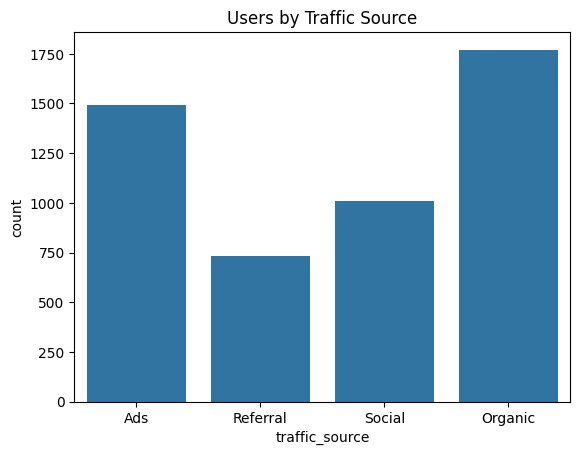

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='traffic_source')
plt.title("Users by Traffic Source")
plt.show()

In [26]:
df['device_type'].value_counts()

device_type
Mobile     2576
Desktop    1942
Tablet      482
Name: count, dtype: int64

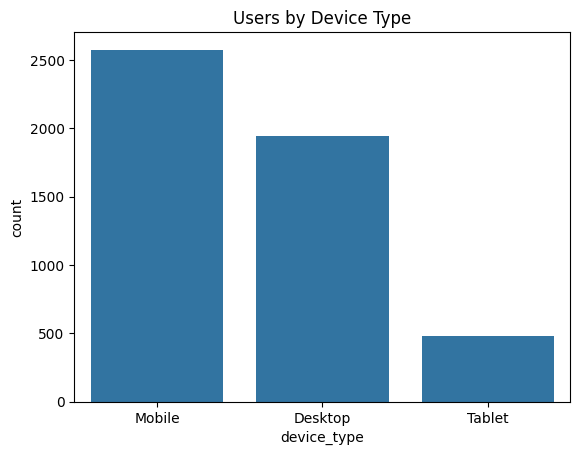

In [27]:
sns.countplot(data=df, x='device_type')
plt.title("Users by Device Type")
plt.show()

In [28]:
df['region'].value_counts()

region
South    1265
East     1261
West     1257
North    1217
Name: count, dtype: int64

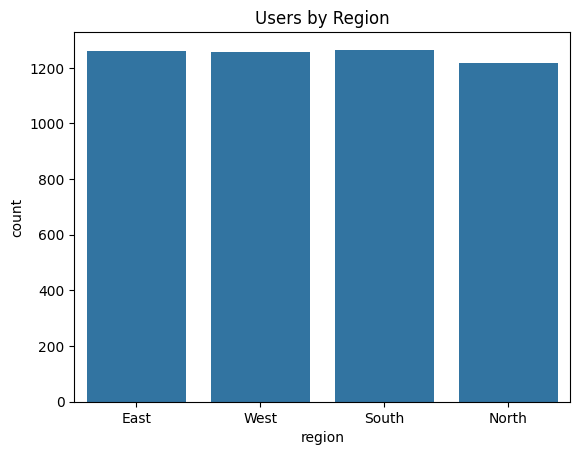

In [29]:
sns.countplot(data=df, x='region')
plt.title("Users by Region")
plt.show()

In [30]:
df['variant'].value_counts()

variant
B    2515
A    2485
Name: count, dtype: int64

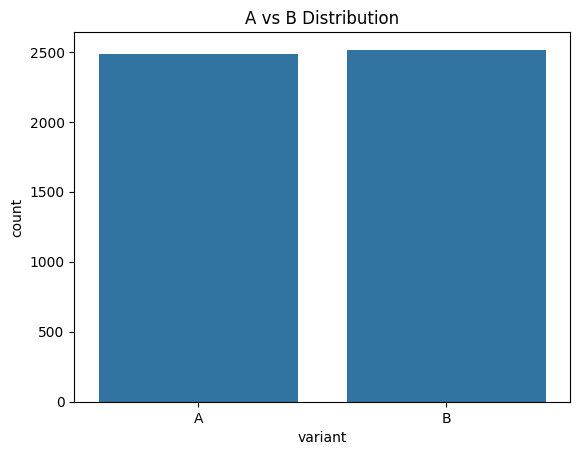

In [31]:
sns.countplot(data=df, x='variant')
plt.title("A vs B Distribution")
plt.show()

In [32]:
df['time_spent_min'].describe()

count    5000.000000
mean        7.997438
std         2.437399
min         1.000000
25%         6.300000
50%         8.020000
75%         9.630000
max        17.030000
Name: time_spent_min, dtype: float64

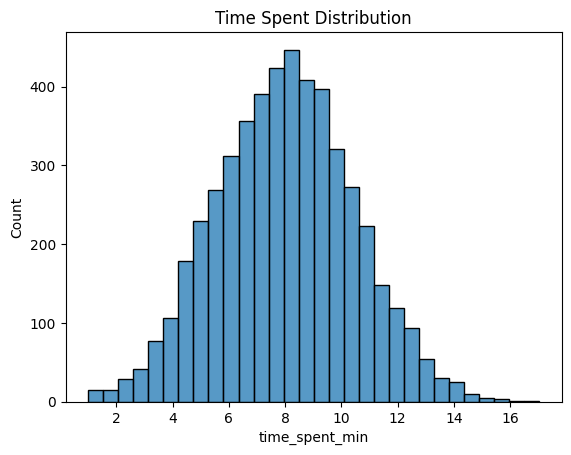

In [33]:
sns.histplot(df['time_spent_min'], bins=30)
plt.title("Time Spent Distribution")
plt.show()

In [34]:
df['session_count'].describe()

count    5000.000000
mean        3.020400
std         1.401134
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: session_count, dtype: float64

In [35]:
df[['visited_site',
    'viewed_product',
    'added_to_cart',
    'started_checkout',
    'completed_payment']].sum()

visited_site         5000
viewed_product       3998
added_to_cart        2131
started_checkout     1295
completed_payment     911
dtype: int64

In [36]:
print("View Rate:", df['viewed_product'].mean())
print("Cart Rate:", df['added_to_cart'].mean())
print("Checkout Rate:", df['started_checkout'].mean())
print("Payment Rate:", df['completed_payment'].mean())

View Rate: 0.7996
Cart Rate: 0.4262
Checkout Rate: 0.259
Payment Rate: 0.1822


In [37]:
df.groupby('device_type')['completed_payment'].mean()

device_type
Desktop    0.179197
Mobile     0.185947
Tablet     0.174274
Name: completed_payment, dtype: float64

In [38]:
df.groupby('traffic_source')['completed_payment'].mean()

traffic_source
Ads         0.175839
Organic     0.177866
Referral    0.167123
Social      0.210109
Name: completed_payment, dtype: float64

In [39]:
df.groupby('region')['completed_payment'].mean()

region
East     0.188739
North    0.192276
South    0.169960
West     0.178202
Name: completed_payment, dtype: float64

In [40]:
# Step 8: Funnel Metrics (CORE STEP)

import pandas as pd

df = pd.read_csv('../data/cleaned_data.csv')

In [41]:
funnel_counts = {
    'Visited Site': df['visited_site'].sum(),
    'Viewed Product': df['viewed_product'].sum(),
    'Added to Cart': df['added_to_cart'].sum(),
    'Started Checkout': df['started_checkout'].sum(),
    'Completed Payment': df['completed_payment'].sum()
}

funnel_df = pd.DataFrame(list(funnel_counts.items()), columns=['Stage', 'Users'])
funnel_df

,Stage,Users
0,Visited Site,5000
1,Viewed Product,3998
2,Added to Cart,2131
3,Started Checkout,1295
4,Completed Payment,911


In [42]:
funnel_df['Conversion Rate'] = funnel_df['Users'].pct_change().fillna(1)
funnel_df['Conversion Rate'] = funnel_df['Conversion Rate'].apply(lambda x: round(x, 2))

funnel_df

,Stage,Users,Conversion Rate
0,Visited Site,5000,1.00
1,Viewed Product,3998,-0.20
2,Added to Cart,2131,-0.47
3,Started Checkout,1295,-0.39
4,Completed Payment,911,-0.30


In [43]:
funnel_df['Conversion Rate'] = funnel_df['Users'] / funnel_df['Users'].shift(1)
funnel_df.loc[0, 'Conversion Rate'] = 1
funnel_df['Conversion Rate'] = funnel_df['Conversion Rate'].round(2)

In [44]:
funnel_df['Drop-off Rate'] = 1 - funnel_df['Conversion Rate']
funnel_df['Drop-off Rate'] = funnel_df['Drop-off Rate'].round(2)

funnel_df

,Stage,Users,Conversion Rate,Drop-off Rate
0,Visited Site,5000,1.00,0.00
1,Viewed Product,3998,0.80,0.20
2,Added to Cart,2131,0.53,0.47
3,Started Checkout,1295,0.61,0.39
4,Completed Payment,911,0.70,0.30


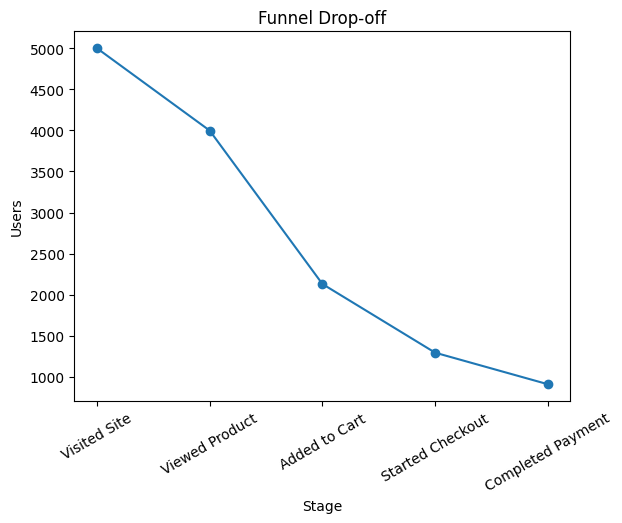

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(funnel_df['Stage'], funnel_df['Users'], marker='o')
plt.title("Funnel Drop-off")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.xticks(rotation=30)
plt.show()

In [46]:
funnel_df.sort_values(by='Drop-off Rate', ascending=False)

,Stage,Users,Conversion Rate,Drop-off Rate
2,Added to Cart,2131,0.53,0.47
3,Started Checkout,1295,0.61,0.39
4,Completed Payment,911,0.70,0.30
1,Viewed Product,3998,0.80,0.20
0,Visited Site,5000,1.00,0.00


In [47]:
# Step 9: Segment Analysis

import pandas as pd

df = pd.read_csv('../data/cleaned_data.csv')

In [48]:
device_conversion = df.groupby('device_type')['completed_payment'].mean().reset_index()
device_conversion

,device_type,completed_payment
0,Desktop,0.179197
1,Mobile,0.185947
2,Tablet,0.174274


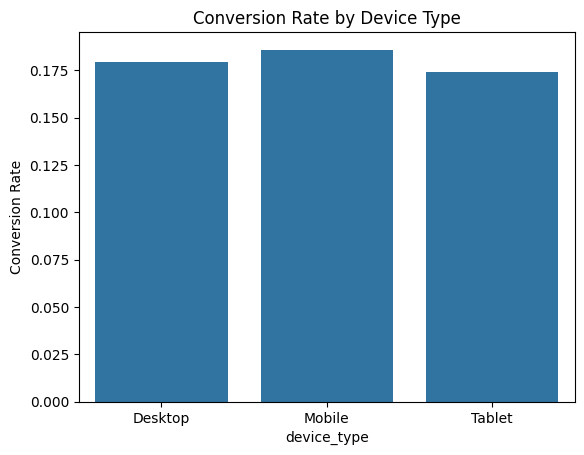

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=device_conversion, x='device_type', y='completed_payment')
plt.title("Conversion Rate by Device Type")
plt.ylabel("Conversion Rate")
plt.show()

In [50]:
traffic_conversion = df.groupby('traffic_source')['completed_payment'].mean().reset_index()
traffic_conversion

,traffic_source,completed_payment
0,Ads,0.175839
1,Organic,0.177866
2,Referral,0.167123
3,Social,0.210109


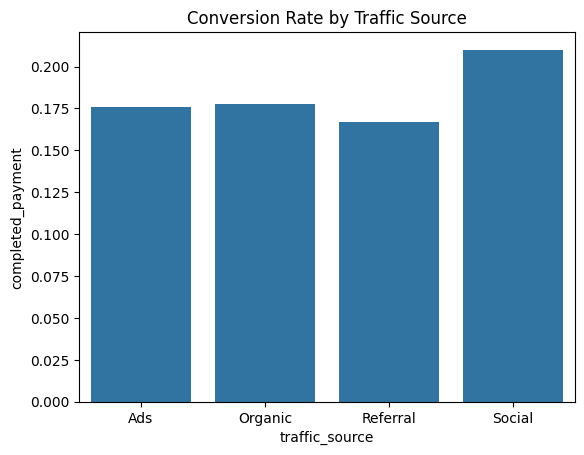

In [51]:
sns.barplot(data=traffic_conversion, x='traffic_source', y='completed_payment')
plt.title("Conversion Rate by Traffic Source")
plt.show()

In [52]:
region_conversion = df.groupby('region')['completed_payment'].mean().reset_index()
region_conversion

,region,completed_payment
0,East,0.188739
1,North,0.192276
2,South,0.169960
3,West,0.178202


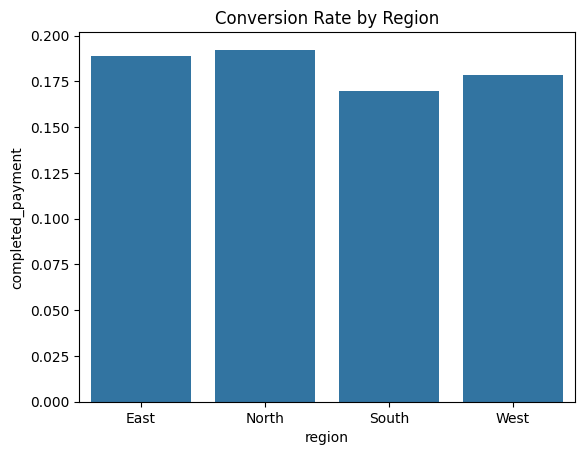

In [53]:
sns.barplot(data=region_conversion, x='region', y='completed_payment')
plt.title("Conversion Rate by Region")
plt.show()

In [54]:
variant_conversion = df.groupby('variant')['completed_payment'].mean().reset_index()
variant_conversion

,variant,completed_payment
0,A,0.193159
1,B,0.171372


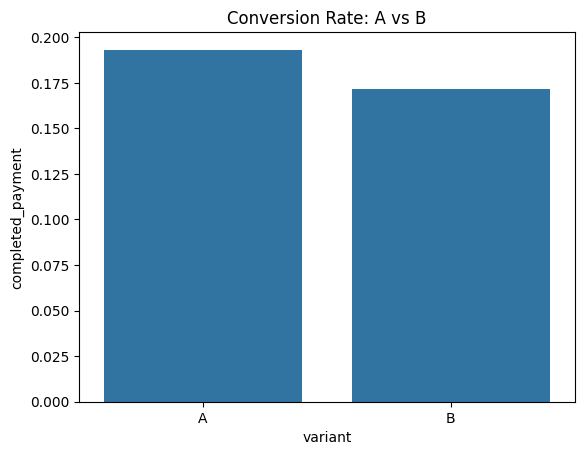

In [55]:
sns.barplot(data=variant_conversion, x='variant', y='completed_payment')
plt.title("Conversion Rate: A vs B")
plt.show()

In [56]:
df.groupby(['traffic_source','device_type'])['completed_payment'].mean().unstack()

device_type,Desktop,Mobile,Tablet
traffic_source,,,
Ads,0.173835,0.174583,0.189542
Organic,0.170767,0.181718,0.186047
Referral,0.172185,0.174648,0.109589
Social,0.207161,0.217228,0.178571


In [57]:
# Step 10: A/B Testing (Statistical Analysis)

import pandas as pd

df = pd.read_csv('../data/cleaned_data.csv')

In [58]:
conversion = df.groupby('variant')['completed_payment'].agg(['mean', 'count', 'sum'])
conversion

,mean,count,sum
variant,,,
A,0.193159,2485,480
B,0.171372,2515,431


In [59]:
from statsmodels.stats.proportion import proportions_ztest

# success counts
success = conversion['sum'].values

# total observations
nobs = conversion['count'].values

# perform test
stat, p_value = proportions_ztest(success, nobs)

print("Z-stat:", stat)
print("P-value:", p_value)

Z-stat: 1.9954946031655316
P-value: 0.045988962179078365


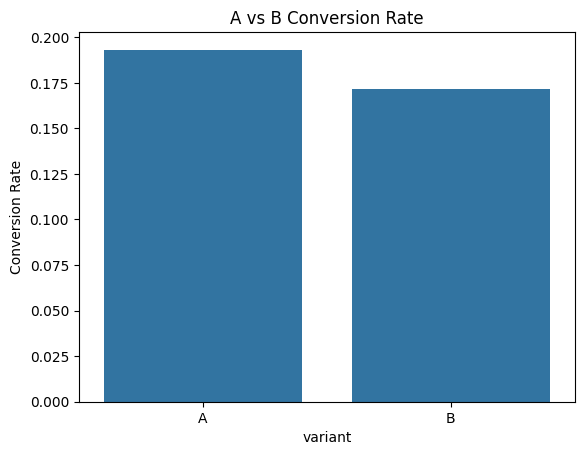

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=conversion.index, y=conversion['mean'])
plt.title("A vs B Conversion Rate")
plt.ylabel("Conversion Rate")
plt.show()

In [61]:
# step 11: Recommendations (Decision Layer)

recommendations = [
    ["High drop-off at Add to Cart stage",
     "Cart conversion rate is lowest",
     "Improve product page UX, pricing clarity, and CTA visibility"],

    ["Low mobile conversion",
     "Mobile users have lower checkout completion",
     "Optimize mobile checkout experience"],

    ["Poor Ads traffic performance",
     "Ads traffic has lower conversion rate",
     "Improve ad targeting and landing pages"],

    ["Variant B performs better",
     "Higher conversion in B variant",
     "Consider rolling out Variant B"]
]

import pandas as pd
rec_df = pd.DataFrame(recommendations, columns=["Issue", "Evidence", "Recommendation"])
rec_df

,Issue,Evidence,Recommendation
0,High drop-off at Add to Cart stage,Cart conversion rate is lowest,"Improve product page UX, pricing clarity, and ..."
1,Low mobile conversion,Mobile users have lower checkout completion,Optimize mobile checkout experience
2,Poor Ads traffic performance,Ads traffic has lower conversion rate,Improve ad targeting and landing pages
3,Variant B performs better,Higher conversion in B variant,Consider rolling out Variant B


In [63]:
funnel_counts = {
    'Stage': ['Visited Site', 'Viewed Product', 'Added to Cart', 'Started Checkout', 'Completed Payment'],
    'Users': [
        df['visited_site'].sum(),
        df['viewed_product'].sum(),
        df['added_to_cart'].sum(),
        df['started_checkout'].sum(),
        df['completed_payment'].sum()
    ]
}

import pandas as pd
funnel_stage_df = pd.DataFrame(funnel_counts)
funnel_stage_df.to_csv('../data/funnel_stage_summary.csv', index=False)